<a href="https://colab.research.google.com/github/algroznykh/notebooks/blob/master/klein_ca_spectral_loss.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

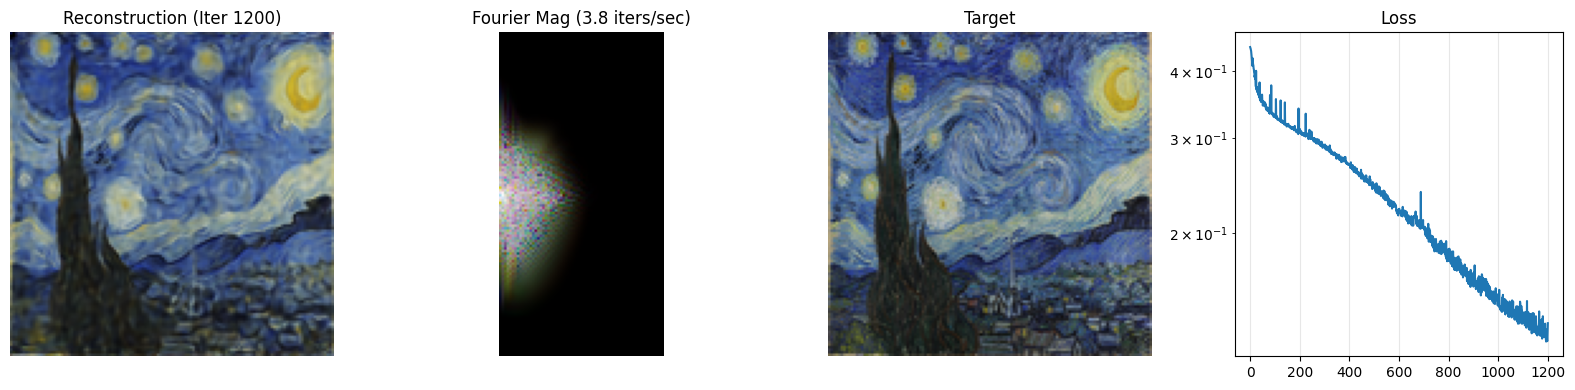

In [ ]:
# Self-contained Jupyter Cell: High-Fidelity Fourier NCA with Circular Padding & Hybrid Loss

import torch
import torch.nn as nn
import torch.nn.functional as F
import numpy as np
import time
import random
import requests
from PIL import Image
import io
import matplotlib.pyplot as plt
from IPython.display import display, clear_output

if torch.cuda.is_available():
    torch.backends.cudnn.benchmark = True

# =========================================================
# 1. CONFIGURATION
# =========================================================
CFG = {
    "size": 128,
    "ch": 32,               # Increased capacity for better detail representation
    "steps_min": 64,
    "steps_max": 96,
    "lr": 2.0e-3,           # Slightly elevated learning rate for faster convergence
    "device": "cuda" if torch.cuda.is_available() else "cpu",
    "target_url": "https://i.imgur.com/VSUuXCA.png",
    "pool_size": 128,
    "batch_size": 4
}


# =========================================================
# 2. HERMITIAN-ALIGNED LOCAL CA MODEL
# =========================================================
class FourierCA(nn.Module):
    def __init__(self, ch, height, limit=4.0):
        super().__init__()
        self.ch = ch
        self.limit = limit

        self.conv1 = nn.Conv2d(ch * 2, ch * 4, 3, padding=0, bias=False)
        self.act = nn.SiLU()
        self.conv2 = nn.Conv2d(ch * 4, ch * 2, 1, bias=False)

        nn.init.kaiming_normal_(self.conv1.weight, nonlinearity='relu')
        nn.init.kaiming_normal_(self.conv2.weight, nonlinearity='linear')
        self.conv1.weight.data *= 0.1
        self.conv2.weight.data *= 0.1

        # Register symmetry indices as a buffer to avoid redundant computation
        y0 = height // 2
        idx = (2 * y0 - torch.arange(height)) % height
        self.register_buffer("idx", idx, persistent=False)

    def forward(self, s):
        B, C, H, W_fft = s.shape

        # 1. Continuous Boundary Padding
        # Left boundary: conjugate mirror of column 1
        left_pad = s.index_select(2, self.idx)[:, :, :, 1:2].clone()
        left_pad[:, self.ch:] *= -1.0

        # Right boundary: conjugate mirror of column W_fft-2 (Nyquist mirror)
        right_pad = s.index_select(2, self.idx)[:, :, :, -2:-1].clone()
        right_pad[:, self.ch:] *= -1.0

        # Continuous horizontal concatenation
        s_h = torch.cat([left_pad, s, right_pad], dim=3)

        # Vertical periodic wrapping (circular padding) to eliminate boundary leaks
        s_pad = F.pad(s_h, (0, 0, 1, 1), mode="circular")

        # Convolve
        h = self.act(self.conv1(s_pad))
        ds = self.conv2(h)

        # Pointwise update using stable step size dt = 0.1
        dt = 0.1
        s_new = s + dt * ds

        # 2. Pointwise Magnitude Squashing
        mag = torch.sqrt(s_new[:, :self.ch]**2 + s_new[:, self.ch:]**2 + 1e-8)
        scale = self.limit * torch.tanh(mag / self.limit) / mag
        s_scaled = s_new * torch.cat([scale, scale], dim=1)

        # Enforce vertical conjugate symmetry on boundary columns (optimized index mapping)
        s_flipped_sym = s_scaled.index_select(2, self.idx)
        s_scaled[:, :self.ch, :, 0] = 0.5 * (s_scaled[:, :self.ch, :, 0] + s_flipped_sym[:, :self.ch, :, 0])
        s_scaled[:, self.ch:, :, 0] = 0.5 * (s_scaled[:, self.ch:, :, 0] - s_flipped_sym[:, self.ch:, :, 0])
        s_scaled[:, :self.ch, :, -1] = 0.5 * (s_scaled[:, :self.ch, :, -1] + s_flipped_sym[:, :self.ch, :, -1])
        s_scaled[:, self.ch:, :, -1] = 0.5 * (s_scaled[:, self.ch:, :, -1] - s_flipped_sym[:, self.ch:, :, -1])

        return s_scaled


class FourierNCA(nn.Module):
    def __init__(self, ch, height, limit=4.0):
        super().__init__()
        self.ch = ch
        self.ca = FourierCA(ch, height, limit)

        # Expanded Pointwise MLP to decode spatial states to RGB
        self.decoder = nn.Sequential(
            nn.Conv2d(ch, ch * 2, 1),
            nn.SiLU(),
            nn.Conv2d(ch * 2, ch, 1),
            nn.SiLU(),
            nn.Conv2d(ch, 3, 1)
        )

        for m in self.decoder.modules():
            if isinstance(m, nn.Conv2d):
                nn.init.kaiming_normal_(m.weight, nonlinearity='relu')
                if m.bias is not None:
                    nn.init.zeros_(m.bias)

    def forward(self, s):
        return self.ca(s)

    def to_rgb(self, s, H, W):
        z = torch.complex(s[:, :self.ch], s[:, self.ch:])
        z_unshifted = torch.fft.ifftshift(z, dim=-2)
        spatial = torch.fft.irfft2(z_unshifted, s=(H, W), norm='ortho')
        return torch.sigmoid(self.decoder(spatial))


# =========================================================
# 3. AUXILIARY LOSS FUNCTIONS
# =========================================================
def image_gradients(img):
    """Computes first-order spatial gradients to enforce sharp details."""
    dx = img[:, :, :, 1:] - img[:, :, :, :-1]
    dy = img[:, :, 1:, :] - img[:, :, :-1, :]
    return dx, dy

def gradient_loss(img1, img2):
    dx1, dy1 = image_gradients(img1)
    dx2, dy2 = image_gradients(img2)
    return F.l1_loss(dx1, dx2) + F.l1_loss(dy1, dy2)


# =========================================================
# 4. TARGET IMAGE ACQUISITION
# =========================================================
def get_target(url, size, device):
    try:
        headers = {'User-Agent': 'Mozilla/5.0'}
        response = requests.get(url, headers=headers, timeout=10)
        img = Image.open(io.BytesIO(response.content)).convert('RGB')
        img = img.resize((size, size), Image.Resampling.LANCZOS)
        target = torch.from_numpy(np.array(img)).permute(2, 0, 1).float() / 255.0
        print("Successfully fetched target image.")
    except Exception as e:
        print(f"Could not load image from URL ({e}). Falling back to procedural target.")
        y, x = torch.meshgrid(
            torch.linspace(-1, 1, size, device=device),
            torch.linspace(-1, 1, size, device=device),
            indexing='ij'
        )
        target = torch.zeros(3, size, device=device)
        target[0] = (torch.sin(10 * x) * torch.cos(10 * y) > 0.0).float()
        target[1] = (torch.sin(20 * x) > 0.0).float()
        target[2] = (torch.cos(20 * y) > 0.0).float()

    if target.ndim == 3:
        target = target.unsqueeze(0)
    return target.to(device)


# =========================================================
# 5. VISUALIZATION UTILITY
# =========================================================
def plot_progress(losses_history, rec_img, tgt_img, z_coeff, step, fps):
    mag = torch.abs(z_coeff[:3]).detach().cpu()
    mag_log = torch.log1p(mag)
    t_mag = (mag_log - mag_log.min()) / (mag_log.max() - mag_log.min() + 1e-8)
    mag_img = (t_mag.permute(1, 2, 0).numpy() * 255).astype(np.uint8)

    clear_output(wait=True)
    fig, axes = plt.subplots(1, 4, figsize=(16, 4))

    axes[0].imshow(rec_img)
    axes[0].set_title(f"Reconstruction (Iter {step})")
    axes[0].axis('off')

    axes[1].imshow(mag_img)
    axes[1].set_title(f"Fourier Mag ({fps:.1f} iters/sec)")
    axes[1].axis('off')

    axes[2].imshow(tgt_img)
    axes[2].set_title("Target")
    axes[2].axis('off')

    axes[3].plot(losses_history, color='#1f77b4')
    axes[3].set_title("Loss")
    axes[3].set_yscale('log')
    axes[3].grid(True, alpha=0.3)

    plt.tight_layout()
    plt.show()


# =========================================================
# 6. EXECUTION
# =========================================================
device = CFG["device"]
H, W = CFG["size"], CFG["size"]
W_fft = W // 2 + 1
ch = CFG["ch"]

model = FourierNCA(ch, H).to(device)
opt = torch.optim.AdamW(model.parameters(), lr=CFG["lr"], weight_decay=1e-4)
scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(opt, T_max=2000, eta_min=1e-5)
target = get_target(CFG["target_url"], CFG["size"], device)

# Precompute target values and spectrum
target_expanded = target.expand(CFG["batch_size"], -1, -1, -1)
tgt_fft = torch.fft.rfft2(target_expanded, norm='ortho')
tgt_mag_log = torch.log1p(torch.abs(tgt_fft)).detach()

# Precompute target seed values for fast initialization
c_indices = torch.arange(ch, device=device, dtype=torch.float32)
seed_val = 1.0 + 0.2 * torch.sin(c_indices)

# Initialize State Pool in RFFT space
pool = torch.zeros(CFG["pool_size"], 2 * ch, H, W_fft, dtype=torch.float32, device=device)
pool[:, :ch, H // 2, 0] = seed_val.unsqueeze(0)

losses_gpu = []
t0 = time.time()

for i in range(0, 2001):
    idx = torch.randperm(CFG["pool_size"], device=device)[:CFG["batch_size"]]

    s = pool[idx].clone()
    s[0] = 0.0
    s[0, :ch, H // 2, 0] = seed_val

    progress = i / 2000
    step_scale = 0.5 + 0.5 * progress
    cur_min = int(CFG["steps_min"] * step_scale)
    cur_max = int(CFG["steps_max"] * step_scale)
    num_steps = random.randint(cur_min, cur_max)

    for _ in range(num_steps):
        s = model(s)

    # Decode states using pointwise spatial MLP
    rgb = model.to_rgb(s, H, W)

    # 1. Spatial Reconstruction Loss
    loss_spatial = F.l1_loss(rgb, target_expanded)

    # 2. Gradient Edge Loss (for sharp details and high-frequency structures)
    loss_grad = gradient_loss(rgb, target_expanded)

    # 3. Log-Spectral Loss (balances low and high frequency attention)
    rgb_fft = torch.fft.rfft2(rgb, norm='ortho')
    loss_spec_mag = F.l1_loss(torch.log1p(torch.abs(rgb_fft)), tgt_mag_log)
    loss_spec_phase = F.l1_loss(torch.view_as_real(rgb_fft), torch.view_as_real(tgt_fft))

    # Combined hybrid objective
    loss = loss_spatial * 1.0 + loss_grad * 2.0 + loss_spec_mag * 0.5 + loss_spec_phase * 0.1

    opt.zero_grad(set_to_none=True)
    loss.backward()

    torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
    opt.step()
    scheduler.step()

    pool[idx] = s.detach()
    losses_gpu.append(loss.detach())

    if i % 100 == 0 or i == 2000:
        fps = 100 / (time.time() - t0)
        t0 = time.time()

        losses_cpu = torch.stack(losses_gpu).cpu().numpy()

        rec_img = (rgb[0].detach().cpu().clamp(0, 1).permute(1, 2, 0).numpy() * 255).astype(np.uint8)
        tgt_img = (target[0].cpu().clamp(0, 1).permute(1, 2, 0).numpy() * 255).astype(np.uint8)

        z = torch.complex(s[0, :ch], s[0, ch:])
        plot_progress(losses_cpu, rec_img, tgt_img, z, i, fps)

In [ ]:
param_n = sum(p.numel() for p in model.parameters())
print('CA param count:', param_n)
loss

CA param count: 48531


tensor(0.0652, device='cuda:0', grad_fn=<AddBackward0>)

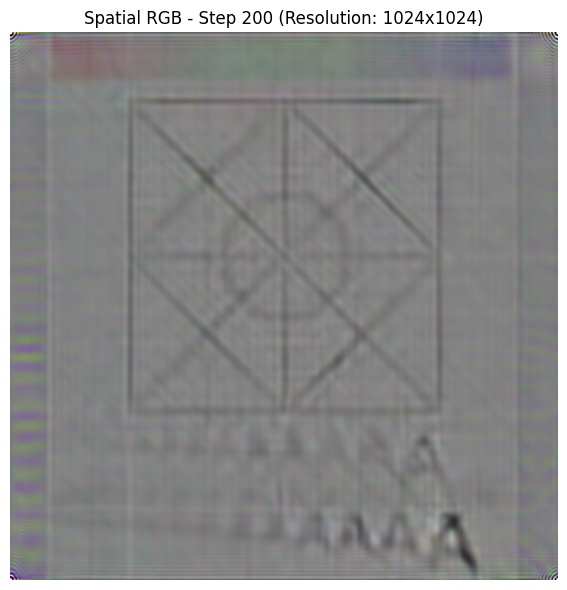

In [ ]:
# =========================================================
# 7. INTERACTIVE MODEL UNROLL FROM SEED
# =========================================================
@torch.no_grad()
def unroll_from_seed(model, size=128, steps=200, mode='both'):
    """
    Unrolls the Fourier CA step-by-step from a single, clean seed bin.
    Supports arbitrary resolution upscaling and different visualization modes.

    Parameters:
    -----------
    model : nn.Module
        Trained FourierCA model.
    size : int
        Inference resolution (e.g., 128, 256, 512).
    steps : int
        Number of steps to run the CA.
    mode : str
        'rgb' (spatial only), 'fourier' (spectrum only), or 'both' (side-by-side).
    """
    device = next(model.parameters()).device
    ch = model.ch
    H, W = size, size
    W_fft = W // 2 + 1

    # 1. Initialize a single, clean state from the symmetry-broken seed
    s = torch.zeros(1, 2 * ch, H, W_fft, dtype=torch.float32, device=device)
    for c in range(ch):
        s[0, c, H // 2, 0] = 1.0 + 0.2 * np.sin(c)

    print(f"Starting unroll at resolution {H}x{W}...")

    for step in range(steps + 1):
        if step > 0:
            s = model(s)

        # Reconstruction: Unshift vertical axis and perform inverse RFFT
        z = torch.complex(s[:, :ch], s[:, ch:])
        z_unshifted = torch.fft.ifftshift(z, dim=-2)
        spatial = torch.fft.irfft2(z_unshifted, s=(H, W), norm='ortho')
        rgb = torch.sigmoid(spatial[0, :3]).clamp(0, 1).cpu().permute(1, 2, 0).numpy()

        # Fourier Magnitude visualization (log-scaled for visibility)
        mag = torch.abs(z[0, :3]).cpu()
        mag_log = torch.log1p(mag)
        t_mag = (mag_log - mag_log.min()) / (mag_log.max() - mag_log.min() + 1e-8)
        mag_img = t_mag.permute(1, 2, 0).numpy()

        # Live plot rendering
        clear_output(wait=True)
        if mode == 'rgb':
            fig, ax = plt.subplots(1, 1, figsize=(6, 6))
            ax.imshow(rgb)
            ax.set_title(f"Spatial RGB - Step {step} (Resolution: {size}x{size})")
            ax.axis('off')
        elif mode == 'fourier':
            fig, ax = plt.subplots(1, 1, figsize=(6, 6))
            ax.imshow(mag_img)
            ax.set_title(f"Fourier Magnitude - Step {step} (Resolution: {size}x{size})")
            ax.axis('off')
        else: # 'both'
            fig, axes = plt.subplots(1, 2, figsize=(12, 6))
            axes[0].imshow(rgb)
            axes[0].set_title(f"Spatial RGB - Step {step} (Resolution: {size}x{size})")
            axes[0].axis('off')

            axes[1].imshow(mag_img)
            axes[1].set_title(f"Fourier Magnitude (Shifted RFFT) - Step {step}")
            axes[1].axis('off')

        plt.tight_layout()
        plt.show()
        time.sleep(0.01)  # Brief pause for visual smoothness

# Run the unroll after training
# Try setting size=256 and running for 300 steps to see the pattern upscale!
unroll_from_seed(model, size=1024, steps=200, mode='rgb')